In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from dotenv import load_dotenv

# On charge les credentials AWS depuis le .env
print("Chargement des variables d'environnement...")
load_dotenv("../.env")
print("...fait")

# Chemins S3 vers les données traitées
BUCKET = os.getenv("S3_BUCKET")
PROC   = f"s3://{BUCKET}/processed"

print(f"Bucket : {BUCKET}")

In [ ]:
df = pd.read_csv(f"{PROCESSED}/dataset_prepared.csv")
df["date"] = pd.to_datetime(df["date"])

# On encode : est-ce que la meilleure équipe (rang le plus faible) a gagné ?
# "upset" = l'équipe moins bien classée l'emporte
def categorize(row):
    if row["home_score"] > row["away_score"]:   winner_rank = row["rank_home"]
    elif row["home_score"] < row["away_score"]: winner_rank = row["rank_away"]
    else:                                        return "Nul"
    
    better_rank = min(row["rank_home"], row["rank_away"])
    return "Favori gagne" if winner_rank == better_rank else "Upset"

df["outcome"] = df.apply(categorize, axis=1)
df["rank_dif"] = df["rank_home"] - df["rank_away"]
df["goal_dif"] = df["home_score"] - df["away_score"]

print(df.shape)
df.head()

## 1. À quelle fréquence le favori (FIFA) gagne-t-il ?

Question clé : est-ce que le classement FIFA est un bon prédicteur ?

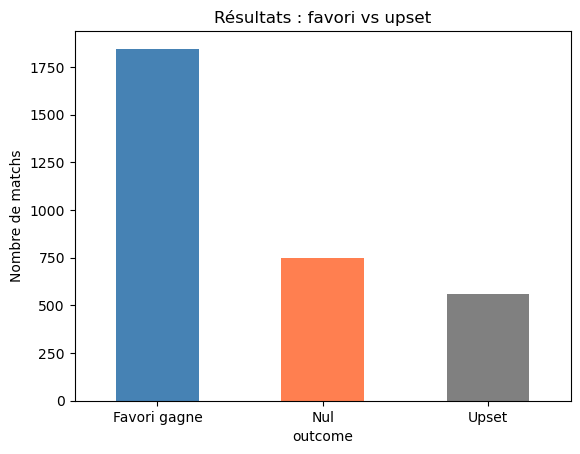

Favori gagne : 1845 matchs (58.5%)
Nul : 746 matchs (23.7%)
Upset : 561 matchs (17.8%)


In [3]:
df["outcome"].value_counts().plot(kind="bar", color=["steelblue", "coral", "gray"])
plt.title("Résultats : favori vs upset")
plt.xticks(rotation=0)
plt.ylabel("Nombre de matchs")
plt.show()

total = len(df)
for label, count in df["outcome"].value_counts().items():
    print(f"{label} : {count} matchs ({count/total*100:.1f}%)")

## 2. L'écart de classement change-t-il la fréquence des upsets ?

Un écart de 5 rangs vs 50 rangs — est-ce que ça fait une différence ?

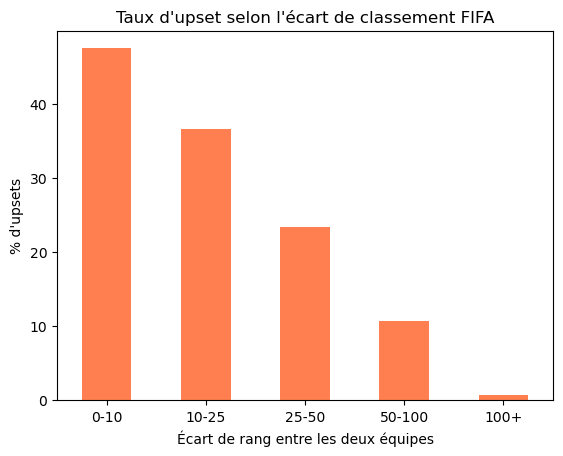

In [4]:
# On ne garde que les matchs avec un vainqueur (on exclut les nuls)
decided = df[df["outcome"] != "Nul"].copy()
decided["rank_gap"] = abs(decided["rank_dif"])

# On découpe en tranches d'écart de classement
decided["gap_bucket"] = pd.cut(decided["rank_gap"], bins=[0, 10, 25, 50, 100, 200],
                                labels=["0-10", "10-25", "25-50", "50-100", "100+"])

upset_rate = decided.groupby("gap_bucket", observed=True)["outcome"].apply(
    lambda x: (x == "Upset").mean() * 100
)

upset_rate.plot(kind="bar", color="coral")
plt.title("Taux d'upset selon l'écart de classement FIFA")
plt.ylabel("% d'upsets")
plt.xlabel("Écart de rang entre les deux équipes")
plt.xticks(rotation=0)
plt.show()

## 3. Amical vs officiel — les résultats sont-ils différents ?

Les amicaux ont moins d'enjeu. Est-ce que les upsets y sont plus fréquents ?

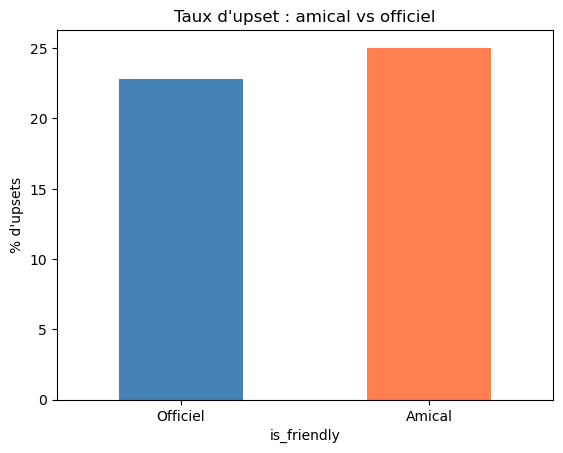

In [6]:
decided["is_friendly"] = decided["tournament"] == "Friendly"

upset_by_type = decided.groupby("is_friendly")["outcome"].apply(
    lambda x: (x == "Upset").mean() * 100
).rename({False: "Officiel", True: "Amical"})

upset_by_type.plot(kind="bar", color=["steelblue", "coral"])
plt.title("Taux d'upset : amical vs officiel")
plt.ylabel("% d'upsets")
plt.xticks(rotation=0)
plt.show()

## 4. Les points FIFA et les buts sont-ils corrélés ?

On vérifie que les points FIFA reflètent bien le niveau offensif des équipes.

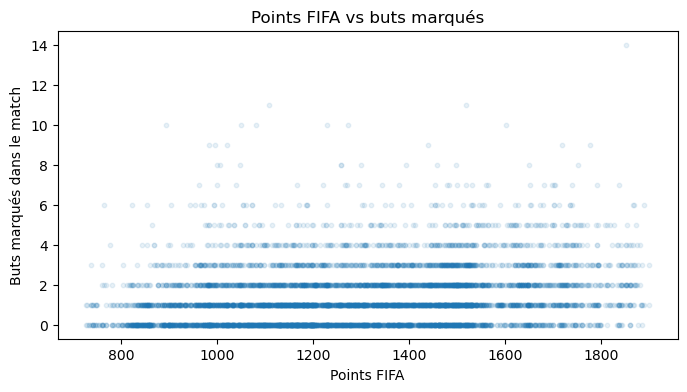

Corrélation points FIFA / buts : 0.223


In [7]:
# On empile domicile et extérieur pour avoir une vue par équipe
home = df[["total_points_home", "home_score"]].rename(columns={"total_points_home": "points", "home_score": "buts"})
away = df[["total_points_away", "away_score"]].rename(columns={"total_points_away": "points", "away_score": "buts"})
combined = pd.concat([home, away])

plt.figure(figsize=(8, 4))
plt.scatter(combined["points"], combined["buts"], alpha=0.1, s=10)
plt.xlabel("Points FIFA")
plt.ylabel("Buts marqués dans le match")
plt.title("Points FIFA vs buts marqués")
plt.show()

corr = combined.corr().iloc[0, 1]
print(f"Corrélation points FIFA / buts : {corr:.3f}")

## 5. Les équipes de la CDM 2026 sont-elles bien représentées ?

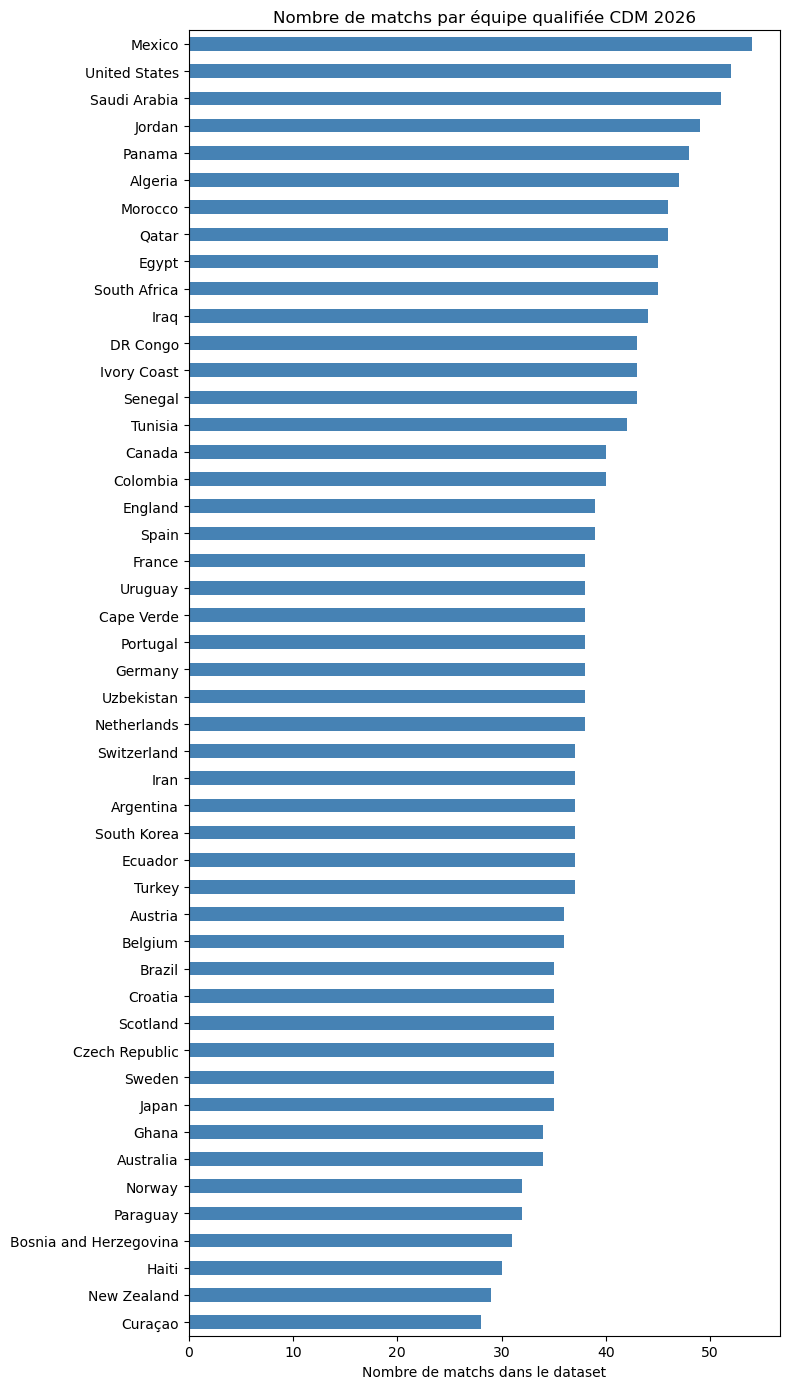

Équipe avec le moins de matchs : Curaçao (28)
Équipe avec le plus de matchs : Mexico (54)


In [8]:
equipes_wc2026 = [
    "Algeria", "Argentina", "Australia", "Austria", "Belgium", "Bosnia and Herzegovina",
    "Brazil", "Canada", "Cape Verde", "Colombia", "Croatia", "Curaçao", "Czech Republic",
    "DR Congo", "Ecuador", "Egypt", "England", "France", "Germany", "Ghana", "Haiti",
    "Iran", "Iraq", "Ivory Coast", "Japan", "Jordan", "Mexico", "Morocco", "Netherlands",
    "New Zealand", "Norway", "Panama", "Paraguay", "Portugal", "Qatar", "Saudi Arabia",
    "Scotland", "Senegal", "South Africa", "South Korea", "Spain", "Sweden", "Switzerland",
    "Tunisia", "Turkey", "United States", "Uruguay", "Uzbekistan"
]

toutes = set(df["home_team"]) | set(df["away_team"])
nb_matchs = {}
for eq in equipes_wc2026:
    n = len(df[(df["home_team"] == eq) | (df["away_team"] == eq)])
    nb_matchs[eq] = n

matchs_serie = pd.Series(nb_matchs).sort_values()

matchs_serie.plot(kind="barh", figsize=(8, 14), color="steelblue")
plt.title("Nombre de matchs par équipe qualifiée CDM 2026")
plt.xlabel("Nombre de matchs dans le dataset")
plt.tight_layout()
plt.show()

print(f"Équipe avec le moins de matchs : {matchs_serie.idxmin()} ({matchs_serie.min()})")
print(f"Équipe avec le plus de matchs : {matchs_serie.idxmax()} ({matchs_serie.max()})")